# Residual Network
作为大二计算机专业、已掌握CNN基础的学生，学习ResNet的核心是**抓住“解决深度网络痛点”的核心思路+关键结构+实践逻辑**，无需陷入复杂公式推导，重点突破以下6个核心模块，就能快速掌握ResNet的精髓：


### 一、先搞懂：ResNet为什么会出现？（核心痛点）
在ResNet之前，人们认为“网络越深，性能越好”，但实际遇到了两个致命问题：
1. **梯度消失/爆炸**（早期痛点）：深层网络反向传播时，梯度会变得极小或极大，导致浅层参数无法更新。  
   ✅ 已部分解决：通过Batch Normalization（BN层）、合理的权重初始化，让梯度能“传递下去”。
2. **退化问题（Degradation）**（ResNet要解决的核心）：当网络深度超过一定阈值（比如20层），**训练误差和测试误差都会上升**（不是过拟合！过拟合是训练误差小、测试误差大）。  
   📌 关键原因：深层网络难以学习“恒等映射”（即输入=输出）——比如给一个已训练好的20层网络加20层“无效层”（输入直接输出），理论上性能应不变，但实际模型学不会这种简单的恒等映射，导致性能下降。

ResNet的核心贡献：**通过“残差连接”，让模型轻松学习恒等映射，从而突破深度限制**（最深做到152层，甚至1000+层）。


### 二、核心思想：残差学习（Residual Learning）
#### 1. 传统CNN的映射逻辑
对于深层网络中的某几层，传统CNN希望这几层直接学习“目标映射” \( H(x) \)（x是输入，H(x)是这几层的理想输出）。

#### 2. ResNet的残差映射逻辑
ResNet不直接学 \( H(x) \)，而是让这几层学习“残差映射” \( F(x) = H(x) - x \)，最终的输出变为：  
\( y = F(x) + x \)  
- 其中 \( F(x) \) 是“残差”（目标输出与输入的差值），由卷积层等学习；  
- \( x \) 是输入，通过“ shortcut connection（ shortcut连接）”直接加到输出端（无参数、无计算量）。

#### 3. 为什么这样更优？
- 若理想映射 \( H(x) = x \)（恒等映射），则只需让 \( F(x) = 0 \)（即残差为0），模型只需把卷积层的权重置为0即可，比直接学恒等映射简单得多；  
- 若理想映射不是恒等映射，模型只需学习“输入到目标输出的差值”，降低了学习难度。


输入 x → [Conv2d(3×3) → BN → ReLU → Conv2d(3×3) → BN] → F(x) → F(x) + x → ReLU → 输出 y
                ↑                                        ↑
                └────────────────  shortcut连接  ─────────┘

<img src = "imgs/ResBlock.png">

- Formally, denoting the desired underlying mapping as H(x), we let the stacked nonlinear layers fit another mapping of F(x) := H(x)−x. The original mapping is recast into F(x)+x. 
- We hypothesize that it is easier to optimize the residual mapping than to optimize the original, unreferenced mapping.

残差输出就是恒等映射加上差值，这样的话如果模型想要学习恒等映射，也就是残差为0的情况，或者类似层输出很小的，更容易学习，因为梯度消失问题在深层神经网络格外显著而梯度极小，具有使得残差接近0的好处

$$
y = \mathcal{F}(x, {W_i}) + x\space\space(1)
$$

其中，$\mathcal{F} = W_2\sigma(W_1x) $, 为了简化标记，$\sigma(W_1x)$表示ReLu激活加上bias
 

- x的维度可能和 $\mathcal{F}(x, W_i)$ 不同， 因此可以线性映射x
$$y = \mathcal{F}(x,{W_i})+W_sx   \space\space(2)$$
也可以采用squre matrix的 $W_i$ 维持维度
- residual 函数$\mathcal{F}$是灵活的，没有固定形式，如果多层layers允许的话，通常有多层layers,如果只有单层layer,等式(1)相当于$y=W_1x+x$，相当一`单层普通的线型层`，失去了残差连接的优势
- 函数 $\mathcal{F}(x,{W_i})$ 可以表示多层conv层，$\mathcal{F}(x,{W_i})$ 和 x 这里是逐元素加法，并且对应channel加上对应channel

# 手势识别
### 这里用手势识别进行测试，同时对比两者性能

In [1]:
import numpy as np
import os
import h5py

def load_dataset():
    train_dataset = h5py.File('datasets/train_signs.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('datasets/test_signs.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

img_train, labels_train, imgs_test, labels_test, classes = load_dataset()
print(img_train.shape) # (1080, 64, 64, 3)
print(labels_train.shape) # (1, 1080)
print(imgs_test.shape) # (120, 64, 64, 3)
print(labels_test.shape) # (1, 120)
print(classes) # [0 1 2 3 4 5]

(1080, 64, 64, 3)
(1, 1080)
(120, 64, 64, 3)
(1, 120)
[0 1 2 3 4 5]


In [2]:
def convert_to_one_hot(Y, C):
    if Y.ndim == 1:
        Y = Y.reshape(-1,1) # (num_examples, 1)
    elif (Y.ndim == 2 and Y.shape[0] == C):
        Y = Y.T # (num_examples, C)
    Y = np.eye(C)[Y] # (num_examples, C)
    return Y

# 说明
Y = [2, 0, 4]  # 3个样本的标签
# np.eye(5)[Y] 等价于：
result = [
    np.eye(5)[2],  # 取第2行: [0, 0, 1, 0, 0]
    np.eye(5)[0],  # 取第0行: [1, 0, 0, 0, 0]
    np.eye(5)[4]   # 取第4行: [0, 0, 0, 0, 1]
]

In [3]:
A = img_train.transpose(0,3,1,2) # (1080, 3, 64, 64)
y = labels_train.T # CNN 自带onehot转换，不需要再转换 
A_test = imgs_test.transpose(0,3,1,2)
y_test = labels_test.T

In [4]:
from CNN_v4_cupy import *

🚀 [Backend] Using CuPy (GPU Acceleration)


Loading model from models/resnet_pose_recognition.npz...
Resuming training from epoch 100 with LR=0.00036603234127322915
Model loaded successfully.
Training with 1080 samples, batch_size=16, num_batches=68
Epoch 100/120 Batch 0/68  cost: 0.356565
Epoch 100/120 Batch 13/68  cost: 0.192940
Epoch 100/120 Batch 26/68  cost: 0.040940
Epoch 100/120 Batch 39/68  cost: 0.034784
Epoch 100/120 Batch 52/68  cost: 0.070461
Epoch 100/120 Batch 65/68  cost: 0.060476
Cost after epoch 0: 0.077010
Model saved to models/resnet_pose_recognition.npz
Epoch 101/120 Batch 0/68  cost: 0.202584
Epoch 101/120 Batch 13/68  cost: 0.037785
Epoch 101/120 Batch 26/68  cost: 0.083835
Epoch 101/120 Batch 39/68  cost: 0.060286
Epoch 101/120 Batch 52/68  cost: 0.028393
Epoch 101/120 Batch 65/68  cost: 0.072365
Cost after epoch 1: 0.037200
Model saved to models/resnet_pose_recognition.npz
Epoch 102/120 Batch 0/68  cost: 0.004731
Epoch 102/120 Batch 13/68  cost: 0.121308
Epoch 102/120 Batch 26/68  cost: 0.035392
Epoch 102

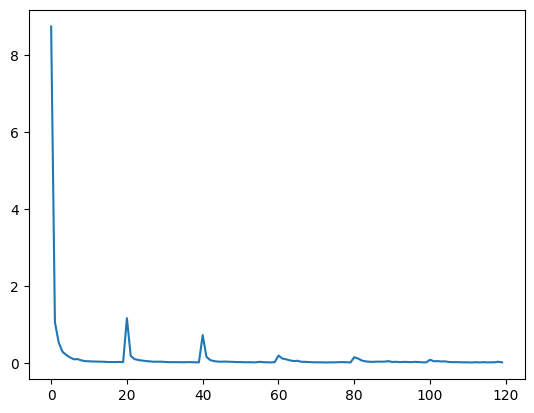

In [5]:
save_path = 'models/resnet_pose_recognition.npz'
cnn = None
resblock = ResBlock(Layers=[
    Conv(filter_num = 6,filter_channel=3,filter_size=4,stride=1,_Adam=1,same_padding=True),
    BatchNorm(_Adam=1),
    Conv(filter_num = 16,filter_channel=6,filter_size=5,stride=1,_Adam=1,same_padding=True),
    BatchNorm(_Adam=1),
    Conv(filter_num = 64,filter_channel=16,filter_size=6,stride=1,_Adam=1,same_padding=True),
    BatchNorm(_Adam=1),
    Activation('relu'),
    Pooling(pool_size=2,stride=2,pool_type='avg'),
]
,connected_layer=5
)

if os.path.exists(save_path) == 0:
    cnn=CNN(layers=[
        resblock,
        ResBlock(Layers=[
            FC(output_size=16,_Adam=True),
            # Dropout(0.1),
            BatchNorm(_Adam=True),
            Activation('relu'),# 线性映射，叠加再多层也相当于一层
            FC(output_size=24,_Adam=True),
            # Dropout(0.1),
            BatchNorm(_Adam=True),
            Activation('relu'),# 线性映射，叠加再多层也相当于一层
        ]),

        FC(output_size=6,_Adam=True),
        Activation('softmax'),

    ])
else:
    cnn = CNN.load_model(save_path)
    # cnn.learning_rate = 0.0001

    

cost_history = cnn.train(A / 255.0, y, epochs=20, batch_size=16,  save_path=save_path)
# Evaluate on test set
print("\nEvaluating on test set...")
test_accuracy = cnn.evaluate(A_test / 255.0, y_test)
print(f"Test accuracy: {test_accuracy:.2%}")

print("\nEvaluating on train set...")
train_accuracy = cnn.evaluate(A / 255.0, y)
print(f"Train accuracy: {train_accuracy:.2%}")
# Predict
y_pred = cnn.predict(A_test/255.0)

plt.plot(cost_history)
plt.show()

<img src = "imgs/res.png">

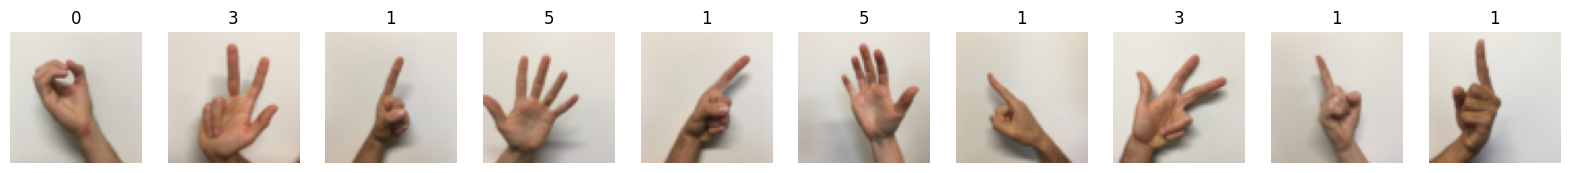

In [6]:
import matplotlib.pyplot as plt

def show_images(images, labels, num_images=10, bias=0):
    plt.figure(figsize=(2 * num_images, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i + bias])  # 这里 images 是 imgs_test
        plt.title(labels[i + bias][0])
        plt.axis('off')
    plt.show()

show_images(imgs_test, y_pred, 10, 5)

In [7]:
# 转换png to np.ndarray
def png_to_array(png_path, target_size=(64, 64), normalize=True):
    """
    将 PNG 图片文件转换为 CNN 模型需要的 numpy 数组格式
    
    参数:
        png_path: PNG 图片文件路径
        target_size: 目标图片尺寸 (height, width)，默认 (64, 64)
        normalize: 是否归一化到 [0, 1]，默认 True
    
    返回:
        img_array: numpy 数组，形状为 (1, C, H, W)，即 (1, 3, 64, 64)
    """
    from PIL import Image
    
    # 1. 读取 PNG 图片
    img = Image.open(png_path)
    
    # 2. 转换为 RGB 格式（如果是 RGBA 或其他格式）
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # 3. 调整图片大小到目标尺寸
    img = img.resize(target_size)
    
    # 4. 转换为 numpy 数组 (H, W, C) = (64, 64, 3)
    img_array = np.array(img, dtype=np.float32)
    
    # 5. 归一化到 [0, 1]（如果启用）
    if normalize:
        img_array = img_array
    
    # 6. 转换为 CNN 需要的格式 (N, C, H, W) = (1, 3, 64, 64)
    img_array = img_array.transpose(2, 0, 1)  # (H, W, C) -> (C, H, W)
    img_array = img_array[np.newaxis, :]  # (C, H, W) -> (1, C, H, W)
    
    return img_array

# 使用示例:
# img_array = png_to_array('path/to/image.png')
# prediction = cnn.predict(img_array)
# probability = cnn.forward(img_array)

(3, 64, 64)


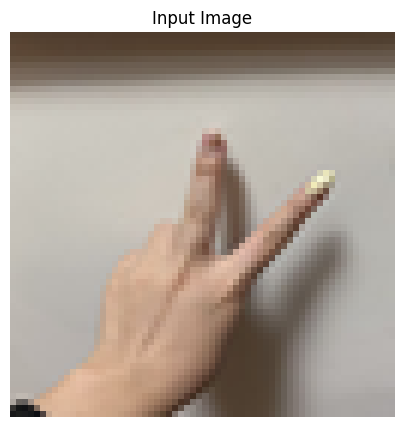

array([[2]])

In [8]:
picture_path="./pictures/2_1.png" 
p_test = png_to_array(picture_path)
print(A_test[0].shape)
# p_test = A_test[1].reshape(1,*A_test[0].shape)
# p_test = np.random.randn(1,3,64,64)

# 显示图片：将 (1, C, H, W) 格式转换为 (H, W, C) 格式
img_to_show = p_test[0].transpose(1, 2, 0)/255.0 # (C, H, W) -> (H, W, C)
plt.figure(figsize=(5, 5))
plt.imshow(img_to_show)
plt.axis('off')
plt.title('Input Image')
plt.show()

p_pred = cnn.predict(p_test/255.0)
p_pred
